In [14]:
import itertools
import numpy as np
import graphviz as gr
from sklearn.linear_model import LinearRegression

## **Causal Shapley values (Heskes et al., NeurIPS 2020)**

Implementation of marginal, conditional and causal Shapley values, in their **symmetric** and **asymmetric** versions, with the direct / indirect decomposition of Section 3.

The value function is $v(S)=\mathbb{E}[f(X)\mid do(X_S=x_S)]$. interventional expectations are sampled with Theorem 1. By default each conditional $P(X_{out}\mid X_{cond})$ is a **linear regression plus the empirical residuals** of the training data (`sampler='residual'`), so the noise can have any distribution (e.g. uniform). The Gaussian model of Aas et al. is still available with `sampler='gaussian'`:

$$P(X_{\bar S}\mid do(X_S=x_S))=\prod_{\tau\in\mathcal T_{\rm confounding}}P(X_{\tau\cap\bar S}\mid X_{pa(\tau)\cap\bar S},x_{pa(\tau)\cap S})\prod_{\tau\notin\mathcal T_{\rm confounding}}P(X_{\tau\cap\bar S}\mid X_{pa(\tau)\cap\bar S},x_{pa(\tau)\cap S},x_{\tau\cap S})$$

## **Two auxiliary functions**

In [2]:
def index_draws(n_train, m, n_comp, rng):
    """(m, n_comp) row indices into the training set, one independent column per chain component.
    With m = n_train each column is a permutation of all rows, so the resampled residuals have
    exactly zero mean (=> exact results for a linear f)."""
    reps = int(np.ceil(m / n_train))
    return np.column_stack([np.concatenate([rng.permutation(n_train) for _ in range(reps)])[:m]
                            for _ in range(n_comp)])


def sample_interventional_residual(S, x, X_train, J, causal_ordering, confounding):
    """NON-GAUSSIAN sampler of P(X_Sbar | do(X_S = x_S)) via Theorem 1.
    Each conditional P(X_out | X_cond) is a LINEAR regression of X_out on X_cond plus EMPIRICAL
    residuals (residual bootstrap); with no conditioning set, rows of the empirical marginal are
    resampled. No assumption on the noise distribution (uniform, skewed, ...).
    J : (m, n_components) row indices from index_draws()."""
    m, d = J.shape[0], len(x)
    n = X_train.shape[0]
    Z = np.empty((m, d))
    for k, comp in enumerate(causal_ordering):
        parents = [j for c in causal_ordering[:k] for j in c]
        inS = [j for j in comp if j in S]
        out = [j for j in comp if j not in S]
        if inS:
            Z[:, inS] = x[inS]
        if not out:
            continue
        cond = parents + ([] if confounding[k] else inS)
        Xo = X_train[:, out]
        if cond:
            A = np.c_[np.ones(n), X_train[:, cond]]
            B = np.linalg.lstsq(A, Xo, rcond=None)[0]
            R = Xo - A @ B                                   # empirical residuals (joint over `out`)
            Z[:, out] = np.c_[np.ones(m), Z[:, cond]] @ B + R[J[:, k]]
        else:
            Z[:, out] = Xo[J[:, k]]
    return Z

## **List all permutations**

In [3]:
def get_permutations(d, causal_ordering, asymmetric, max_perms, rng):
    """All (or max_perms sampled) permutations; asymmetric = consistent with the causal ordering."""
    if asymmetric:
        groups = [list(itertools.permutations(c)) for c in causal_ordering]
        if np.prod([len(g) for g in groups], dtype=float) <= max_perms:
            return [tuple(j for part in combo for j in part) for combo in itertools.product(*groups)]
        return [tuple(j for c in causal_ordering for j in rng.permutation(c)) for _ in range(max_perms)]
    if np.prod(range(1, d + 1), dtype=float) <= max_perms:
        return list(itertools.permutations(range(d)))
    return [tuple(rng.permutation(d)) for _ in range(max_perms)]

## **Calculate Shapley values**

In [4]:
def shapley(f, x, X_train, causal_ordering=None, confounding=False, asymmetric=False, n_samples=None, max_perms=5040, seed=0):
    """Marginal / conditional / causal Shapley values, symmetric or asymmetric.

    f               : (m, d) array -> (m,) predictions
    x               : instance to explain, shape (d,)
    X_train         : (n, d) data used to model P(X)
    causal_ordering : list of lists of feature indices (chain components, in causal order);
                      default = one component with all features
    confounding     : bool or list of bool (one per component). True = dependencies in the
                      component come from a common confounder; False = mutual interactions
    asymmetric      : only use permutations consistent with causal_ordering
    sampler         : 'residual' (default) linear regression + empirical residuals, any noise law
                      'gaussian' multivariate normal fitted on X_train
    n_samples       : Monte-Carlo samples per coalition (default: len(X_train) for 'residual',
                      2000 for 'gaussian')

    marginal               : single component, confounding=True
    symmetric conditional  : single component, confounding=False
    asymmetric conditional : ordering, confounding=False, asymmetric=True
    symmetric causal       : ordering, confounding=[...]
    asymmetric causal      : ordering, confounding=[...], asymmetric=True

    Returns dict(total, direct, indirect, f0, fx).
    """
    x = np.asarray(x, float).ravel()
    X_train = np.asarray(X_train, float)
    d = len(x)
    order = [list(c) for c in (causal_ordering or [list(range(d))])]
    assert sorted(j for c in order for j in c) == list(range(d)), "causal_ordering must partition all features"
    conf = [bool(confounding)] * len(order) if np.isscalar(confounding) else [bool(c) for c in confounding]
    assert len(conf) == len(order)

    rng = np.random.default_rng(seed)
    m = n_samples or X_train.shape[0]
    J = index_draws(X_train.shape[0], m, len(order), rng)   # common random numbers
    draw = lambda S: sample_interventional_residual(S, x, X_train, J, order, conf)

    cache = {}
    def value(S):
        if S not in cache:
            Z = draw(S)
            cache[S] = (Z, f(Z).mean())
        return cache[S]

    perms = get_permutations(d, order, asymmetric, max_perms, rng)
    total, direct = np.zeros(d), np.zeros(d)
    for p in perms:
        S = frozenset()
        for i in p:
            Z, vS = value(S)
            vSi = value(S | {i})[1]
            Z2 = Z.copy(); Z2[:, i] = x[i]       # Eq. (5): replace X_i by x_i, keep do(X_S) distribution
            direct[i] += f(Z2).mean() - vS
            total[i] += vSi - vS
            S = S | {i}
    total /= len(perms); direct /= len(perms)
    return dict(total=total, direct=direct, indirect=total - direct,
                f0=value(frozenset())[1], fx=float(f(x[None])[0]))

## **A toy example**

In his paper Heskes distinguish three patterns **D** (direct only), **E** (indirect credit split evenly between $X_1$ and $X_2$), **R** (all indirect credit to the root cause) that may appear in causal structures. We shall detail below which structures and which indices it may concern

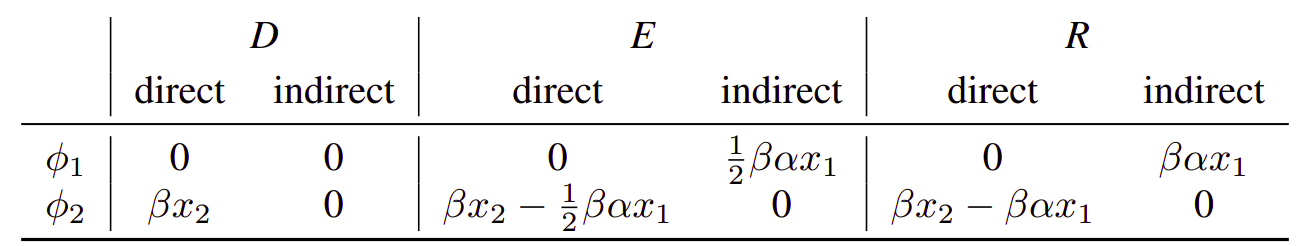

Linear model $f(x_1,x_2)=\beta x_2$ that ignores $x_1$, with $X_1\sim\mathcal N(0,1)$, $E[X_2|x_1]=\alpha x_1$.

## **The chain case**

In [5]:
rng = np.random.default_rng(1)
alpha, beta, n = 1.0, 1.0, 20_000
uniform = lambda std, size: rng.uniform(-np.sqrt(3)*std, np.sqrt(3)*std, size)   # zero mean, given std
X1 = uniform(1.0, n)                       # X1 ~ U(-sqrt3, sqrt3)  (variance 1)
X2 = alpha*X1 + uniform(0.5, n)            # UNIFORM noise, linear structural equation
X = np.c_[X1, X2]
f = lambda Z: beta*Z[:, 1]
x = np.array([1.0, 0.5])
print(f"alpha*beta*x1 = {alpha*beta*x[0]}   beta*x2 = {beta*x[1]}\n")

alpha*beta*x1 = 1.0   beta*x2 = 0.5



In [8]:
chain_cases = {
 # label                (ordering,        confounding, asymmetric, expected pattern)
 'chain  marginal':      ([[0, 1]],        True,  False, 'D'),
 'chain  cond. sym':     ([[0, 1]],        False, False, 'E'),
 'chain  cond. asym':    ([[0], [1]],      False, True,  'R'),
 'chain  causal sym':    ([[0], [1]],      False, False, 'E'),
}


In [9]:
for lab, (order, conf, asym, pat) in chain_cases.items():
    r = shapley(f, x, X, order, conf, asym)
    print(f"{lab:20s} [{pat}] total={np.round(r['total'],3)}  direct={np.round(r['direct'],3)}  indirect={np.round(r['indirect'],3)}")

chain  marginal      [D] total=[0.    0.504]  direct=[0.    0.504]  indirect=[0. 0.]
chain  cond. sym     [E] total=[0.502 0.002]  direct=[0.    0.002]  indirect=[0.502 0.   ]
chain  cond. asym    [R] total=[ 1.004 -0.5  ]  direct=[ 0.  -0.5]  indirect=[1.004 0.   ]
chain  causal sym    [E] total=[0.502 0.002]  direct=[0.    0.002]  indirect=[0.502 0.   ]


## **The fork case**

In [10]:
rng = np.random.default_rng(1)
alpha, beta, n = 1.0, 1.0, 20_000
uniform = lambda std, size: rng.uniform(-np.sqrt(3)*std, np.sqrt(3)*std, size)   # zero mean, given std
X2 = uniform(1.0, n)                       # X1 ~ U(-sqrt3, sqrt3)  (variance 1)
X1 = alpha*X2 + uniform(0.5, n)            # UNIFORM noise, linear structural equation
X = np.c_[X1, X2]
f = lambda Z: beta*Z[:, 1]
x = np.array([1.0, 0.5])
print(f"alpha*beta*x1 = {alpha*beta*x[0]}   beta*x2 = {beta*x[1]}\n")

alpha*beta*x1 = 1.0   beta*x2 = 0.5



In [11]:
fork_cases = {
 # label                (ordering,        confounding, asymmetric, expected pattern)
 'fork   cond. asym':    ([[1], [0]],      False, True,  'D'),
 'fork   causal sym':    ([[1], [0]],      False, False, 'D'),
}

In [12]:
for lab, (order, conf, asym, pat) in fork_cases.items():
    r = shapley(f, x, X, order, conf, asym)
    print(f"{lab:20s} [{pat}] total={np.round(r['total'],3)}  direct={np.round(r['direct'],3)}  indirect={np.round(r['indirect'],3)}")

fork   cond. asym    [D] total=[0.    0.505]  direct=[0.    0.505]  indirect=[0. 0.]
fork   causal sym    [D] total=[0.    0.505]  direct=[0.    0.505]  indirect=[0. 0.]


## **The cycle and confounder**

In [18]:
other_cases = {
 # label                (ordering,        confounding, asymmetric, expected pattern)
 'confounder causal':    ([[0, 1]],        True,  False, 'D'),
 'cycle  causal':        ([[0, 1]],        False, False, 'E'),
}

In [19]:
for lab, (order, conf, asym, pat) in other_cases.items():
    r = shapley(f, x, X, order, conf, asym)
    print(f"{lab:20s} [{pat}] total={np.round(r['total'],3)}  direct={np.round(r['direct'],3)}  indirect={np.round(r['indirect'],3)}")

confounder causal    [D] total=[0.    0.507]  direct=[0.    0.507]  indirect=[0. 0.]
cycle  causal        [E] total=[ 0.75  -0.243]  direct=[ 0.    -0.243]  indirect=[0.75 0.  ]


## **Another toy model : diamond**

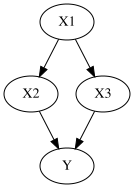

In [13]:
g = gr.Digraph()
g.edge("X1", "X2"), g.edge("X1","X3"), g.edge("X2", "Y"), g.edge("X3","Y")
g

In [15]:
rng = np.random.default_rng(0)
n = 5000; a, b, c, d = 1.5, -1.0, 2.0, 1.0; sigma = 0.5
uniform = lambda std, size: rng.uniform(-np.sqrt(3)*std, np.sqrt(3)*std, size)   # zero mean, given std
X1 = uniform(1.0, n)
X2 = a*X1 + uniform(sigma, n)              # uniform noise, linear structural equations
X3 = b*X1 + uniform(sigma, n)
Y  = c*X2 + d*X3 + uniform(sigma, n)
X = np.column_stack([X1, X2, X3])
model = LinearRegression().fit(X, Y)
x0 = X[0]

The fitted model ignores $X_1$, so marginal SHAP gives it $\approx 0$. With the causal ordering $\{X_1\}\prec\{X_2,X_3\}$, $X_1$ receives credit for its **indirect** effect.

In [16]:
methods = {
 'marginal':          dict(causal_ordering=[[0,1,2]],  confounding=True),
 'conditional sym':   dict(causal_ordering=[[0,1,2]],  confounding=False),
 'conditional asym':  dict(causal_ordering=[[0],[1,2]], confounding=False, asymmetric=True),
 'causal sym':        dict(causal_ordering=[[0],[1,2]], confounding=False),
 'causal asym':       dict(causal_ordering=[[0],[1,2]], confounding=False, asymmetric=True),
}

In [17]:
print("x =", np.round(x0, 3), "\n")
print(f"{'method':18s}{'phi_1':>8s}{'phi_2':>8s}{'phi_3':>8s}   | direct phi_1")
for lab, kw in methods.items():
    r = shapley(model.predict, x0, X, **kw)
    print(f"{lab:18s}" + "".join(f"{v:8.3f}" for v in r['total']) + f"   | {r['direct'][0]:.3f}")
    assert abs(r['f0'] + r['total'].sum() - r['fx']) < 1e-6   # efficiency

x = [ 0.474  1.379 -0.357] 

method               phi_1   phi_2   phi_3   | direct phi_1
marginal            -0.005   2.789  -0.376   | -0.005
conditional sym      0.466   1.634   0.308   | -0.001
conditional asym     0.951   1.347   0.110   | -0.005
causal sym           0.472   2.061  -0.126   | -0.005
causal asym          0.951   1.347   0.110   | -0.005
